#  MuJoCo Bootcamp : Trajectory tracking & Finite State Machines

---- 

- conda env : [ai_robotics](../../../README.md#setup-a-conda-environment)

---

### Reference : 
- https://pab47.github.io/mujoco.html
- https://youtu.be/-oGNxB86YEk

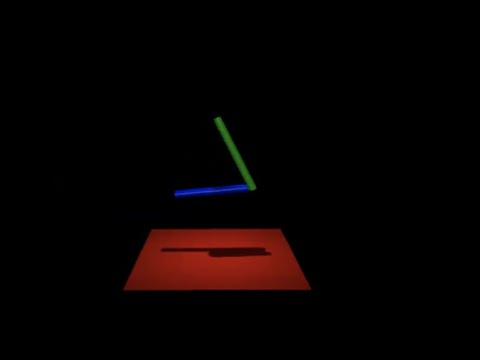

In [7]:
from IPython.display import YouTubeVideo

YouTubeVideo('-oGNxB86YEk')

## Run python code

In [ ]:
!python doublependulum_fsm.py

## Jupyter code

### Load XML file and build model and data

In [1]:
import mujoco as mj
import numpy as np
import mediapy as media

# Create an XML file string for a simple ball on a plane
xml_path = "./doublependulum_fsm.xml" 

# MuJoCo data structures
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

### Setup the controller

In [2]:
t_hold = 0.5
t_swing1 = 1.0
t_swing2 = 1.0

FSM_HOLD = 0
FSM_SWING1 = 1
FSM_SWING2 = 2
FSM_STOP = 3

fsm_state = FSM_HOLD;

# Define setpoints
q_init = np.array([[-1.0], [0.0]])
q_mid = np.array([[0.5], [-2.0]])
q_end = np.array([[1.0], [0.0]])

# Define setpoint times
t_init = t_hold
t_mid = t_hold + t_swing1
t_end = t_hold + t_swing1 + t_swing2

def init_controller(model,data):

    global fsm_state
    global a_swing1, a_swing2
    fsm_state = FSM_HOLD

    a_swing1 = generate_trajectory(
        t_init, t_mid, q_init, q_mid)

    a_swing2 = generate_trajectory(
        t_mid, t_end, q_mid, q_end)

def controller(model, data):
    """
    This function implements a PD controller for tracking
    the reference motion.
    """
    global fsm_state
    global a_swing1, a_swing2
    time = data.time

    # Check for state change
    if fsm_state == FSM_HOLD and time >= t_hold:
        fsm_state = FSM_SWING1
    elif fsm_state == FSM_SWING1 and time >= t_mid:
        fsm_state = FSM_SWING2
    elif fsm_state == FSM_SWING2 and time >= t_end:
        fsm_state = FSM_STOP

    # Get reference joint position & velocity
    if fsm_state == FSM_HOLD:
        q_ref = q_init
        dq_ref = np.zeros((2, 1))
    elif fsm_state == FSM_SWING1:
        q_ref = a_swing1[0] + a_swing1[1]*time + \
            a_swing1[2]*(time**2) + a_swing1[3]*(time**3)
        dq_ref = a_swing1[1] + 2 * a_swing1[2] * \
            time + 3 * a_swing1[3]*(time**2)
    elif fsm_state == FSM_SWING2:
        q_ref = a_swing2[0] + a_swing2[1]*time + \
            a_swing2[2]*(time**2) + a_swing2[3]*(time**3)
        dq_ref = a_swing2[1] + 2 * a_swing2[2] * \
            time + 3 * a_swing2[3]*(time**2)
    elif fsm_state == FSM_STOP:
        q_ref = q_end
        dq_ref = np.zeros((2, 1))

    # Define PD gains
    kp = 500
    kv = 50

    # Compute PD control
    torque = kp * (q_ref[:, 0] - data.qpos) + \
         kv * (dq_ref[:, 0] - data.qvel)

    for i in range(0,6):
        data.ctrl[i]=0

    data.ctrl[0] = torque[0]
    data.ctrl[3] = torque[1]


def generate_trajectory(t0, tf, q0, qf):
    """
    Generates a trajectory
    q(t) = a0 + a1t + a2t^2 + a3t^3
    which satisfies the boundary condition
    q(t0) = q0, q(tf) = qf, dq(t0) = 0, dq(tf) = 0
    """
    tf_t0_3 = (tf - t0)**3
    a0 = qf*(t0**2)*(3*tf-t0) + q0*(tf**2)*(tf-3*t0)
    a0 = a0 / tf_t0_3

    a1 = 6 * t0 * tf * (q0 - qf)
    a1 = a1 / tf_t0_3

    a2 = 3 * (t0 + tf) * (qf - q0)
    a2 = a2 / tf_t0_3

    a3 = 2 * (q0 - qf)
    a3 = a3 / tf_t0_3

    return a0, a1, a2, a3

#set the controller
mj.set_mjcb_control(controller)

### Setup the configuration of render

In [3]:
# Offscreen rendering setup
width, height = 200, 200
renderer = mj.Renderer(model, width, height)

# Set camera configuration
cam = mj.MjvCamera()                        # Abstract camera
opt = mj.MjvOption()                        # visualization options
mj.mjv_defaultCamera(cam)
mj.mjv_defaultOption(opt)
# Set camera configuration
cam.azimuth = 89.608063
cam.elevation = -11.588379
cam.distance = 5.0
cam.lookat = np.array([0.0, 0.0, 1.5])

### Initialization 

In [4]:
# Reset the data to initial state
mj.mj_resetData(model, data)

# Set initial condition
data.qpos[0] = -1
#initialize the controller
init_controller(model,data);

### Simulation

In [5]:
# Store frames for visualization
frames = []
framerate = 60
simend = 5

while data.time < simend:
    simstart = data.time
    # Perform a single simulation step
    while (data.time - simstart < 1.0/60.0):
        mj.mj_step(model, data)
    
    # Render the scene from the specified camera
    renderer.update_scene(data, camera=cam)
    
    # Get the rendered RGB image and store it
    rgb_image = renderer.render()
    frames.append(rgb_image)

media.show_video(frames, fps=framerate)




This browser does not support the video tag.
